# Reproducing the Main Paper Figures

Reproduces the three main spirals figures (**Legendre** embedding, **d10r6** arch).

| Figure | Label | What it shows |
|--------|-------|---------------|
| Fig 1 | `fig:alpha-density` | Distribution heatmaps: at, α=0, 0.5, 1 |
| Fig 2 | `fig:alpha-robustness` | Accuracy/robustness + NLL vs α |
| Fig 3 | `fig:regime-spirals` | Regime barplot: 4 regimes at ε=0.2 |

**Prerequisites**: `conda activate bm4tc` before launching.  
All HPO configs are pre-filled — skip §0 unless you want fresh HPs.

**Sections**: §0 optional HPO · §1 seed sweeps · §2 analysis · §3–5 figures

In [1]:
import sys
from pathlib import Path

# This notebook lives in notebooks/; Jupyter's CWD is that folder. Walk up to the
# repo root (the dir containing src/) so all outputs/analysis/figures paths resolve.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /home/martin-lanigo/projects/bm4tc


---
## §0  [Optional] Re-run HPO and Fill HPs (nat only)

Skip unless you want fresh hyperparameters for the nat runs.
Pre-filled HPs came from `hpo_a0`, `hpo_a05`, `hpo_a1` experiments.

> **at HPO** depends on the nat `seed_sweep_a0` checkpoint — it is in §1 Step 3.

In [2]:
NAT_HPO_CONFIGS = [
    "spirals/nat/legendre/d10r6/hpo_a0",
    "spirals/nat/legendre/d10r6/hpo_a05",
    "spirals/nat/legendre/d10r6/hpo_a1",
]

print("# 1. Run each nat HPO sweep (can run in parallel):")
for cfg in NAT_HPO_CONFIGS:
    print(f"python -m experiments.train --multirun +experiments={cfg}")

print("\n# 2. Fill best HPs into nat seed_sweep configs (after all nat HPO sweeps complete):")
print("python tools/fill_hpo.py --trainer nat --dataset spirals --embedding legendre --arch d10r6")

# 1. Run each nat HPO sweep (can run in parallel):
python -m experiments.train --multirun +experiments=spirals/nat/legendre/d10r6/hpo_a0
python -m experiments.train --multirun +experiments=spirals/nat/legendre/d10r6/hpo_a05
python -m experiments.train --multirun +experiments=spirals/nat/legendre/d10r6/hpo_a1

# 2. Fill best HPs into nat seed_sweep configs (after all nat HPO sweeps complete):
python tools/fill_hpo.py --trainer nat --dataset spirals --embedding legendre --arch d10r6


---
## §1  Run Seed Sweeps

Long-running jobs — recommended to run from a terminal with tmux.
The cell below prints the commands; copy them into separate terminal panes.

> **Run order**:
> 1. Start the three `nat` sweeps and `alpha_curve` (all independent — run in parallel panes).
> 2. After `seed_sweep_a0` finishes: patch model_path in both at configs (`hpo` + `seed_sweep`).
> 3. [Optional if HPs pre-filled] Run at HPO, then fill HPs into `at/seed_sweep`.
> 4. Run the `at/seed_sweep`.

| Kind | Seeds | Used by |
|------|-------|---------|
| `nat/seed_sweep_a0` | 20 | Figs 1, 2 (endpoint), 3 |
| `nat/seed_sweep_a05` | 20 | Fig 3 |
| `nat/seed_sweep_a1` | 20 | Figs 1, 2 (endpoint), 3 |
| `at/seed_sweep` | 8 | Figs 1, 3 — run after nat |
| `nat/alpha_curve` | 10α × 5 seeds | Fig 2 |

In [3]:
NAT_SWEEPS = [
    "spirals/nat/legendre/d10r6/seed_sweep_a0",
    "spirals/nat/legendre/d10r6/seed_sweep_a05",
    "spirals/nat/legendre/d10r6/seed_sweep_a1",
]
ALPHA_CURVE = "spirals/nat/legendre/d10r6/alpha_curve"
AT_SWEEP    = "spirals/at/legendre/d10r6/seed_sweep"
AT_HPO      = "spirals/at/legendre/d10r6/hpo"

# Step 1: nat sweeps + alpha_curve (run in parallel panes)
print("# Step 1 — nat sweeps + alpha_curve (independent; run in parallel panes):")
for cfg in NAT_SWEEPS:
    print(f"python -m experiments.train --multirun +experiments={cfg}")
print(f"python -m experiments.train --multirun +experiments={ALPHA_CURVE}")

# Step 2: patch at model_path (both hpo + seed_sweep configs, after seed_sweep_a0 finishes)
print("\n# Step 2 — patch at model_path (after seed_sweep_a0 finishes):")
print("# Replace DDMM with the actual date suffix of your seed_sweep_a0 output dir.")
print("python tools/patch_checkpoint.py outputs/spirals/nat/legendre/d10r6/seed_sweep_a0_DDMM")
print("# (patches both at/hpo.yaml and at/seed_sweep.yaml by default)")

# Step 3: [Optional] at HPO + fill (skip if HPs already pre-filled in seed_sweep.yaml)
print(f"\n# Step 3 — [Optional] at HPO (skip if lr/weight_decay/clean_weight are pre-filled):")
print(f"python -m experiments.train --multirun +experiments={AT_HPO}")
print("python tools/fill_hpo.py --trainer at --dataset spirals --embedding legendre --arch d10r6")

# Step 4: at sweep (after Steps 2 + 3)
print(f"\n# Step 4 — at sweep:")
print(f"python -m experiments.train --multirun +experiments={AT_SWEEP}")

# Step 1 — nat sweeps + alpha_curve (independent; run in parallel panes):
python -m experiments.train --multirun +experiments=spirals/nat/legendre/d10r6/seed_sweep_a0
python -m experiments.train --multirun +experiments=spirals/nat/legendre/d10r6/seed_sweep_a05
python -m experiments.train --multirun +experiments=spirals/nat/legendre/d10r6/seed_sweep_a1
python -m experiments.train --multirun +experiments=spirals/nat/legendre/d10r6/alpha_curve

# Step 2 — patch at model_path (after seed_sweep_a0 finishes):
# Replace DDMM with the actual date suffix of your seed_sweep_a0 output dir.
python tools/patch_checkpoint.py outputs/spirals/nat/legendre/d10r6/seed_sweep_a0_DDMM
# (patches both at/hpo.yaml and at/seed_sweep.yaml by default)

# Step 3 — [Optional] at HPO (skip if lr/weight_decay/clean_weight are pre-filled):
python -m experiments.train --multirun +experiments=spirals/at/legendre/d10r6/hpo
python tools/fill_hpo.py --trainer at --dataset spirals --embedding legendre --arch d10r6

# Step

---
## §2  Post-hoc Analysis

Fill in the dated output directories below, then run the printed commands from a terminal.

> **Distribution plots (Fig 1)**: Pass `--viz` when analysing the four seed sweeps — this
> generates `decision_boundary.png` + `best_joint.png` needed by §3. Do **not** pass `--viz`
> for `alpha_curve` (distributions there are not used for the main figures).

In [4]:
# Fill in dated output directories after training. Format: {kind}_{DDMM}
SWEEP_DIRS = {
    "seed_sweep_a0":  "outputs/spirals/nat/legendre/d10r6/seed_sweep_a0_3005",
    "seed_sweep_a05": "outputs/spirals/nat/legendre/d10r6/seed_sweep_a05_3005",
    "seed_sweep_a1":  "outputs/spirals/nat/legendre/d10r6/seed_sweep_a1_0506",
    "at_seed_sweep":  "outputs/spirals/at/legendre/d10r6/seed_sweep_0206",
    "alpha_curve":    "outputs/spirals/nat/legendre/d10r6/alpha_curve_0506",
}
VIZ_SWEEPS = {"seed_sweep_a0", "seed_sweep_a05", "seed_sweep_a1", "at_seed_sweep"}

print("# Analysis commands (run from project root):")
for name, sweep_dir in SWEEP_DIRS.items():
    viz = " --viz" if name in VIZ_SWEEPS else ""
    print(f"python analysis/sweep.py {sweep_dir}{viz}")

# Analysis commands (run from project root):
python analysis/sweep.py outputs/spirals/nat/legendre/d10r6/seed_sweep_a0_3005 --viz
python analysis/sweep.py outputs/spirals/nat/legendre/d10r6/seed_sweep_a05_3005 --viz
python analysis/sweep.py outputs/spirals/nat/legendre/d10r6/seed_sweep_a1_0506 --viz
python analysis/sweep.py outputs/spirals/at/legendre/d10r6/seed_sweep_0206 --viz
python analysis/sweep.py outputs/spirals/nat/legendre/d10r6/alpha_curve_0506


---
## §3  Figure 1 — Distribution Panel (`fig:alpha-density`)

Assembles `decision_boundary.png` + `best_joint.png` from the four seed sweep analysis outputs
into a 2×4 grid (columns: at, α=0, α=0.5, α=1). Output: `figures/dists_with_adv.pdf`.

**Requires**: §2 completed with `COMPUTE_DISTRIBUTIONS = True` for the four seed sweeps.

> **Verification**: §2 must be run with `--viz` for the four seed sweeps. Expect 8 PNG files (2 per sweep). Red *'Missing:'* text in the assembled grid means a PNG was not generated.

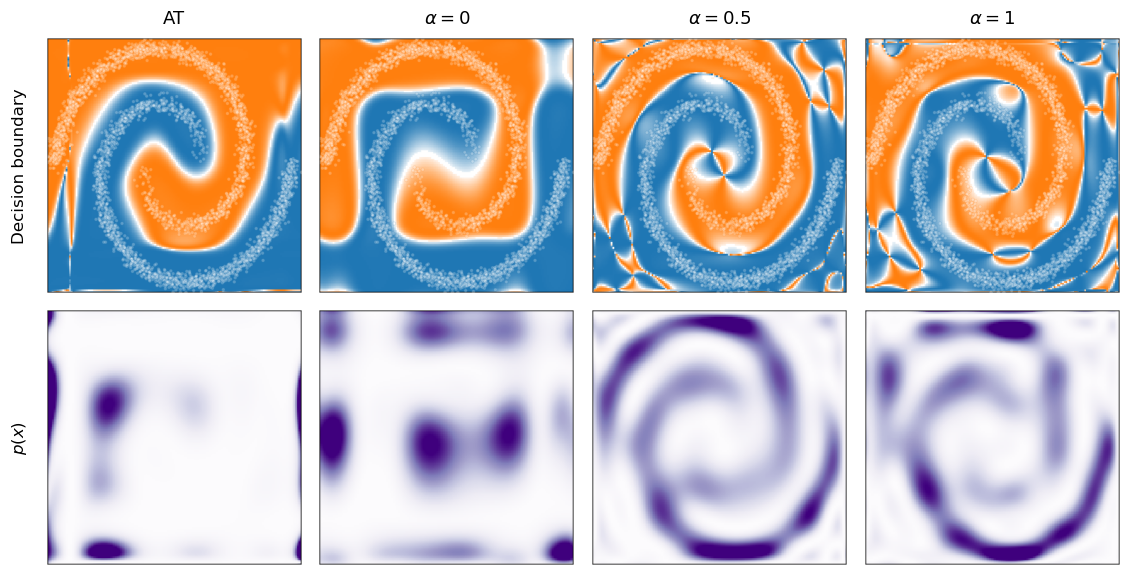

Saved /home/martin-lanigo/projects/bm4tc/figures/dists_with_adv.pdf


In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

COL_KEYS   = ["at_seed_sweep", "seed_sweep_a0", "seed_sweep_a05", "seed_sweep_a1"]
COL_LABELS = ["AT", r"$\alpha=0$", r"$\alpha=0.5$", r"$\alpha=1$"]
ROW_TYPES  = ["decision_boundary", "best_joint"]
ROW_LABELS = ["Decision boundary", r"$p(x)$"]

analysis_dirs = {k: PROJECT_ROOT / "analysis" / SWEEP_DIRS[k] for k in COL_KEYS}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for col, key in enumerate(COL_KEYS):
    adir = analysis_dirs[key]
    for row, fig_type in enumerate(ROW_TYPES):
        ax = axes[row, col]
        png = adir / f"{fig_type}.png"
        if png.exists():
            ax.imshow(np.array(Image.open(png).convert("RGB")))
        else:
            ax.text(0.5, 0.5, f"Missing:\n{png}", ha="center", va="center",
                    transform=ax.transAxes, fontsize=8, color="red")
        ax.axis("off")
        if row == 0:
            ax.set_title(COL_LABELS[col], fontsize=13)
        if col == 0:
            ax.annotate(ROW_LABELS[row], xy=(-0.08, 0.5), xycoords="axes fraction",
                    fontsize=12, rotation=90, ha="center", va="center")

fig.subplots_adjust(hspace=0.02, wspace=0.02)
out = PROJECT_ROOT / "figures/dists_with_adv.pdf"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

---
## §4  Figure 2 — Alpha-Curve Line Plot (`fig:alpha-robustness`)

Accuracy/robustness + NLL vs α. Based on `analysis/visualize/alpha_curve_plots.py`.
The α=0 and α=1 endpoints are overridden with 20-seed data from `seed_sweep_a0`/`seed_sweep_a1`
(the `alpha_curve` multirun has only 5 seeds at those endpoints).
Output: `figures/spirals/alpha/alpha_curve.pdf`.

> **Verification**: Missing columns degrade silently (line absent from plot). Check that `SWEEP_DIRS['alpha_curve']` and both endpoint dirs are filled and analysed.

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Column names — current sweep.py CSV format (no eval/test/ prefix).
# NOTE: analysis/visualize/alpha_curve_plots.py uses the old prefix and is stale;
# update that script separately.
ALPHA_COL       = "config/trainer.generative.criterion.kwargs.alpha"
ACC_COL         = "acc"
ROB_COL         = "rob/0.1"
PURIF_COL       = "uq_purify_acc/0.1/0.1"
GIBBS_PURIF_COL = "gibbs_purify_acc/0.1/1"
DIS_LOSS_COL    = "dis_loss"
GEN_LOSS_COL    = "gen_loss"

_ALPHA_TICKS  = [0, 1e-5, 1e-4, 1e-3, 1e-2, 5e-2, 0.1, 0.5, 0.8, 1.0]
_ALPHA_LABELS = ["0", "1e-5", "1e-4", "1e-3", "1e-2", "5e-2", "0.1", "0.5", "0.8", "1"]


def _load(key, alpha_override=None):
    p = PROJECT_ROOT / "analysis" / SWEEP_DIRS[key] / "evaluation_data.csv"
    df = pd.read_csv(p)
    if alpha_override is not None:
        df[ALPHA_COL] = alpha_override
    return df


def agg(col):
    if col not in df.columns:
        return None
    g = df.groupby(ALPHA_COL)[col].agg(["mean", "std", "count"]).sort_index()
    se = g["std"].fillna(0) / np.sqrt(g["count"].clip(lower=1))
    return g.index.values, g["mean"].values, se.values


def plot_line(ax, res, label, color, ls="-"):
    if res is None:
        return
    a, m, s = res
    ax.plot(a, m, color=color, linestyle=ls, linewidth=1.8, label=label)
    ax.fill_between(a, m - s, m + s, color=color, alpha=0.15)


def setup_xaxis(ax):
    ax.set_xscale("symlog", linthresh=5e-6)
    ax.set_xlim(0, 1)
    ax.set_xticks(_ALPHA_TICKS)
    ax.set_xticklabels(_ALPHA_LABELS, rotation=45, ha="right", fontsize=11)

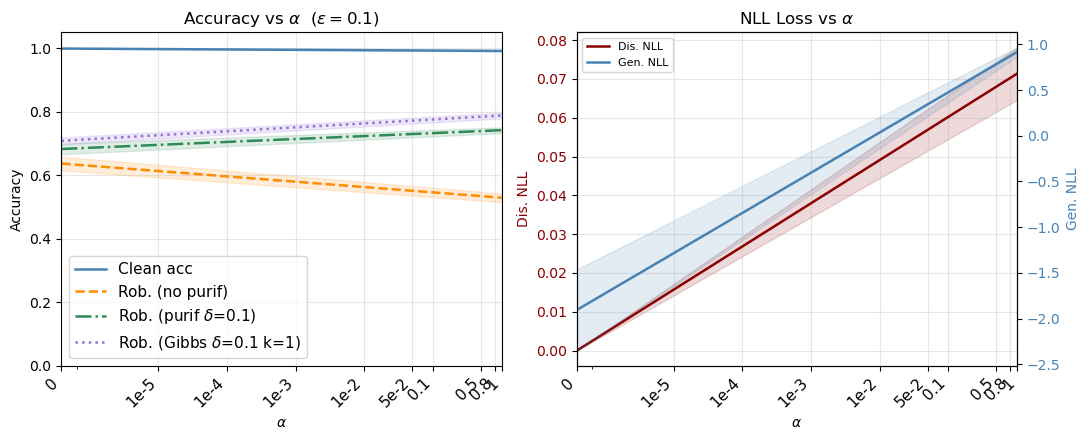

Saved /home/martin-lanigo/projects/bm4tc/figures/spirals/alpha/alpha_curve.pdf


In [7]:
# Drop the 5-seed alpha_curve endpoints; replace with 20-seed dedicated sweeps.
df_ac = _load("alpha_curve")
df_ac = df_ac[~df_ac[ALPHA_COL].isin([0.0, 1.0])]
df = pd.concat([_load("seed_sweep_a0", 0.0), df_ac, _load("seed_sweep_a1", 1.0)],
               ignore_index=True)

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4.5))

# Left panel: accuracy vs alpha
plot_line(ax_l, agg(ACC_COL),         "Clean acc",                      "steelblue",    "-")
plot_line(ax_l, agg(ROB_COL),         "Rob. (no purif)",                "darkorange",   "--")
plot_line(ax_l, agg(PURIF_COL),       r"Rob. (purif $\delta$=0.1)",     "seagreen",     "-.")
plot_line(ax_l, agg(GIBBS_PURIF_COL), r"Rob. (Gibbs $\delta$=0.1 k=1)", "mediumpurple", ":")
ax_l.set_xlabel(r"$\alpha$")
ax_l.set_ylabel("Accuracy")
setup_xaxis(ax_l)
ax_l.set_ylim(0, 1.05)
ax_l.legend(fontsize=11)
ax_l.grid(True, alpha=0.3)
ax_l.set_title(r"Accuracy vs $\alpha$  ($\varepsilon = 0.1$)")

# Right panel: NLL losses vs alpha (dual y-axes)
ax_r2 = ax_r.twinx()
plot_line(ax_r,  agg(DIS_LOSS_COL), "Dis. NLL", "darkred",   "-")
plot_line(ax_r2, agg(GEN_LOSS_COL), "Gen. NLL", "steelblue", "-")
ax_r.set_xlabel(r"$\alpha$")
ax_r.set_ylabel("Dis. NLL", color="darkred")
ax_r2.set_ylabel("Gen. NLL", color="steelblue")
ax_r.tick_params(axis="y", labelcolor="darkred")
ax_r2.tick_params(axis="y", labelcolor="steelblue")
setup_xaxis(ax_r)
ax_r.grid(True, alpha=0.3)
ax_r.set_title(r"NLL Loss vs $\alpha$")
lines = ax_r.get_lines() + ax_r2.get_lines()
if lines:
    ax_r.legend(lines, [l.get_label() for l in lines], fontsize=8)

fig.tight_layout()
out = PROJECT_ROOT / "figures/spirals/alpha/alpha_curve.pdf"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

---
## §5  Figure 3 — Regime Barplot (`fig:regime-spirals`)

Barplot of clean accuracy, robustness, accepted fraction, and purified accuracy for 4 regimes
at ε=0.2. Adapted from `reference/toy_analysis.py` (`cell14_metric_barplots`).
Output: `figures/spirals/regime/metric_eps02.pdf`.

> **Verification**: Zero-height bars mean the CSV was not found or the sweep wasn't analysed. Check `SWEEP_DIRS` entries and re-run `analysis/sweep.py` if needed.

In [8]:
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

USE_LATEX = True  # set False if no LaTeX install
if USE_LATEX:
    matplotlib.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times"],
        "text.latex.preamble": r"\usepackage{mathptmx}",
    })
else:
    matplotlib.rcParams.update({"text.usetex": False})

# Budgets are RELATIVE: fractions of the input domain width (legendre: 2.0).
# These were 0.3 / 0.2 absolute; the AT legend below already read 0.15.
EPS    = 0.15
RADIUS = 0.1


def _L(tex, plain):
    return tex if USE_LATEX else plain


REGIMES = [
    ("at_seed_sweep",  _L(r"Adv. ($\varepsilon{=}0.15$)", "Adv. (eps=0.15)"), "#F44336"),
    ("seed_sweep_a0",  _L(r"Dis. ($\alpha{=}0$)",         "Dis. (a=0)"),      "#2196F3"),
    ("seed_sweep_a05", _L(r"Mix. ($\alpha{=}0.5$)",       "Mix. (a=0.5)"),    "#FF9800"),
    ("seed_sweep_a1",  _L(r"Gen. ($\alpha{=}1$)",         "Gen. (a=1)"),      "#4CAF50"),
]

GROUPS = [
    ("acc",                            _L("Clean",                        "Clean"),        False),
    (f"rob/{EPS}",                     _L("Rob.",                         "Rob."),         False),
    (f"uq_det_err_passed/10pct/{EPS}", _L(r"Accept. ($q{=}10\%$)",       "Accept."),      True),
    (f"uq_purify_acc/{EPS}/{RADIUS}",  _L(r"Purif. (lk.)",               "Purif. (lk.)"), False),
    (f"gibbs_purify_acc/{EPS}/5",      _L(r"Purif. (samp., $k{=}5$)",    "Purif. (k=5)"), False),
]


def load_csv(key):
    p = PROJECT_ROOT / "analysis" / SWEEP_DIRS[key] / "evaluation_data.csv"
    if not p.exists():
        warnings.warn(f"Missing CSV: {p}")
        return pd.DataFrame()
    return pd.read_csv(p)

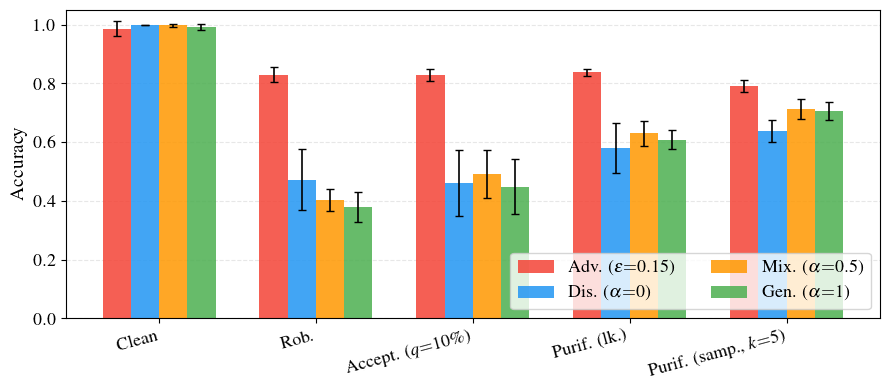

Saved /home/martin-lanigo/projects/bm4tc/figures/spirals/regime/metric_eps02.pdf


In [9]:
dfs = {key: load_csv(key) for key, *_ in REGIMES}

n_g     = len(GROUPS)
n_r     = len(REGIMES)
width   = 0.18
x       = np.arange(n_g)
offsets = (np.arange(n_r) - (n_r - 1) / 2) * width

fig, ax = plt.subplots(figsize=(9, 4))
for i, (key, label, color) in enumerate(REGIMES):
    df = dfs[key]
    means, stds = [], []
    for col, _, flip in GROUPS:
        if df.empty or col not in df.columns:
            means.append(0.0); stds.append(0.0)
            continue
        vals = pd.to_numeric(df[col], errors="coerce").dropna()
        m = float(vals.mean()) if len(vals) > 0 else 0.0
        s = float(vals.std())  if len(vals) > 1 else 0.0
        if flip:
            m = 1.0 - m if np.isfinite(m) else 0.0
        means.append(m); stds.append(s)
    ax.bar(x + offsets[i], means, width, yerr=stds,
           label=label, color=color, capsize=3, alpha=0.85,
           error_kw={"elinewidth": 1.2})

ax.set_xticks(x)
ax.set_xticklabels([g[1] for g in GROUPS], rotation=15, ha="right", fontsize=13)
ax.set_ylabel("Accuracy", fontsize=14)
ax.set_ylim(0, 1.05)
ax.tick_params(axis="y", labelsize=13)
ax.legend(fontsize=13, ncol=2, frameon=True, loc="lower right")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
fig.tight_layout()

out = PROJECT_ROOT / "figures/spirals/regime/metric_eps02.pdf"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved {out}")